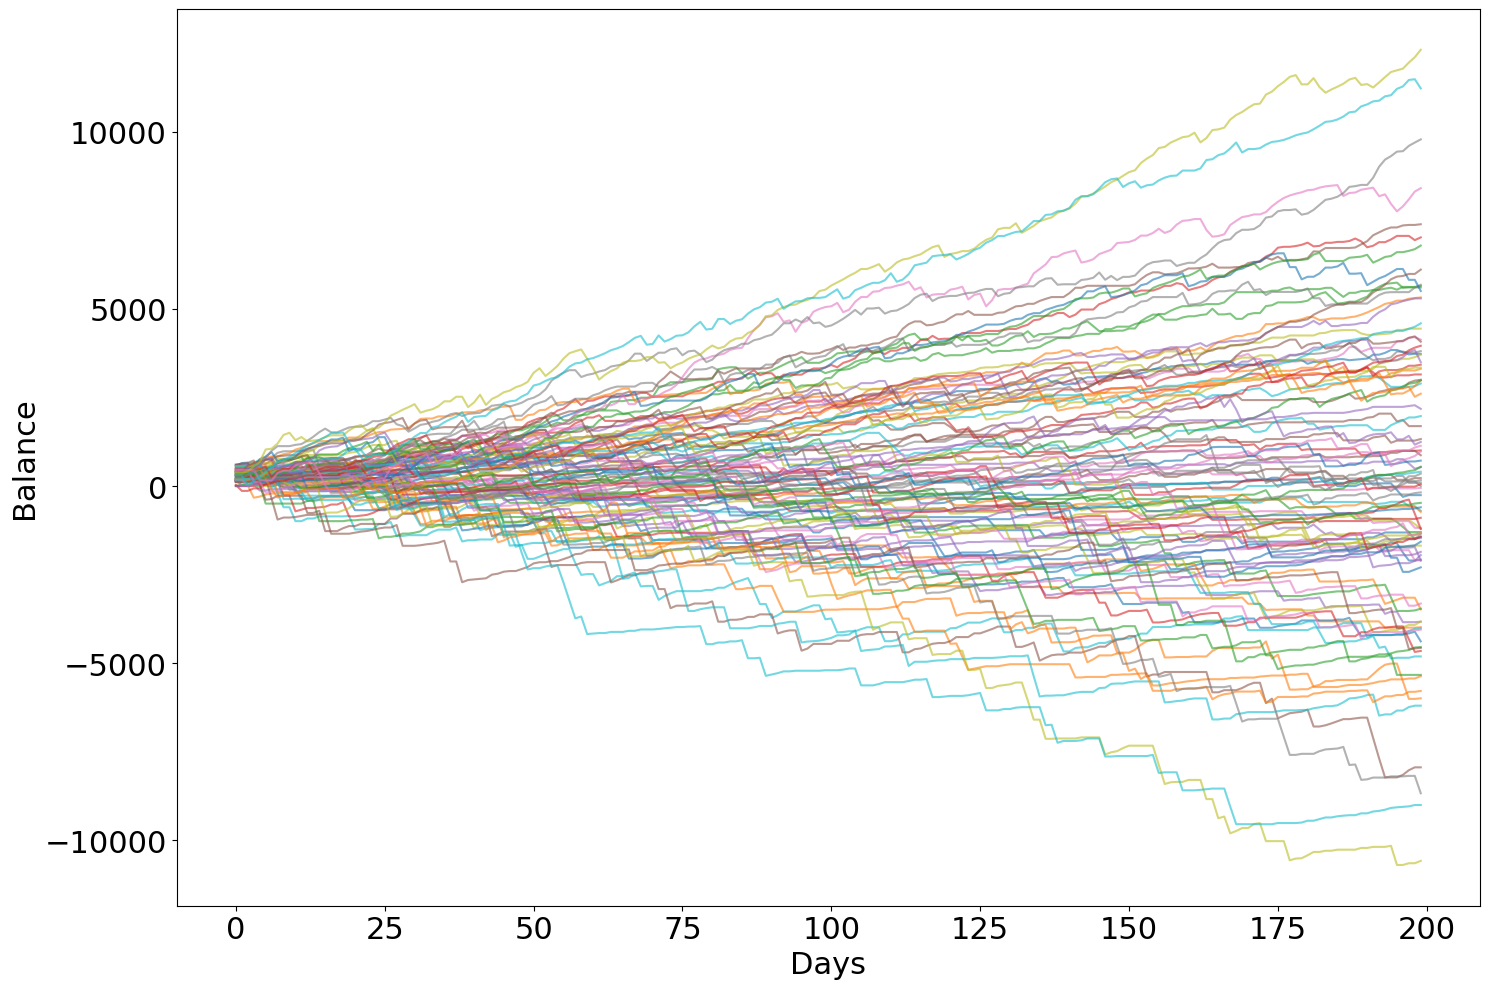

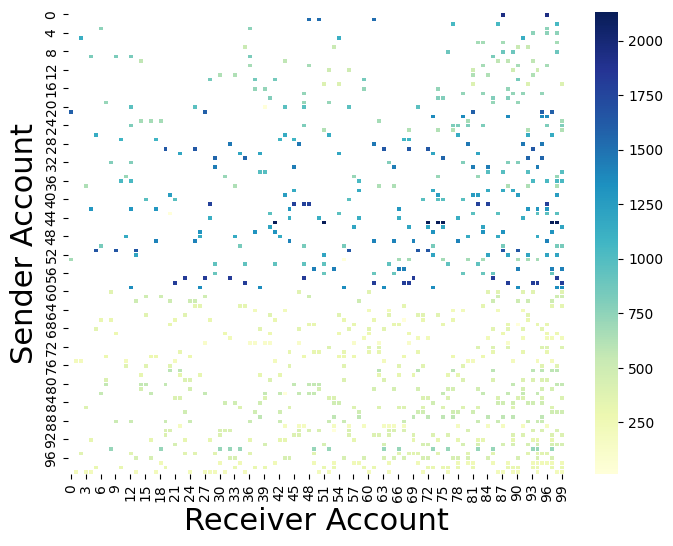


----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    1.590000e+01
 Y:         100 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      9.000000e-01 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* compute sample covariance matrix S: nnz(S)/p=2.96e+01 time=7.80e-04
* iter=1 time=7.32e-03 obj=5.09e+03 |delta(obj)|/obj=9.80e-01 nnz(X,L,W)/p=[2.96e+01 2.21e+01 1.10e+00] lns_iter=3 
* iter=2 time=2.60e-03 obj=4.48e+03 |delta(obj)|/obj=1.37e-01 nnz(X,L,W)/p=[2.96e+01 2.21e+01 5.07e+01] lns_iter=4 
* iter=3 time=8.92e-03 obj=4.22e+03 |de

In [1]:
from workflow.internal import *

# Load dataset (the user will pass the name)
df, name, dimension, account_prop = load_dataset()

# Extract time series
extract_timeseries(df, name)

# Normalise time series
Y_norm = normalization(df, name)

# Create transaction matrix
adj_matrix = adjaceny_matrix(Y_norm, name, dimension)

# Run SQUIC_fit
A_matrices, _ = squic_fit_computation(Y_norm, name, dimension, adj_matrix, printMatrix=False)

In [2]:
# Use the extracted W for clustering
dict_cluster = clustering(A_matrices)

# Report internal metrics on the clustering
int_metrics = internal_metrics(dict_cluster, A_matrices)

100%|██████████| 20/20 [00:00<00:00, 144.66it/s]
/opt/anaconda3/envs/bank/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Best params: eps=0.1, min_samples=3
Best difference in number of clusters: 29.0000
Best difference in number of clusters: 29.0000


100%|██████████| 20/20 [00:00<00:00, 197.32it/s]
/opt/anaconda3/envs/bank/lib/python3.10/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Best params: eps=0.1, min_samples=3
Best difference in number of clusters: 12.0000
Best difference in number of clusters: 12.0000


100%|██████████| 20/20 [00:00<00:00, 194.04it/s]


...

Best params: eps=0.9999999999999999, min_samples=3
Best difference in number of clusters: 0.0000
Best difference in number of clusters: 0.0000


100%|██████████| 20/20 [00:00<00:00, 224.05it/s]


Best params: eps=1.7, min_samples=3
Best difference in number of clusters: 1.0000
Best difference in number of clusters: 1.0000


100%|██████████| 20/20 [00:00<00:00, 214.02it/s]

Best params: eps=0.3, min_samples=3
Best difference in number of clusters: 1.0000
Best difference in number of clusters: 1.0000


In [3]:
visualize_metrics(int_metrics)

For rho = 0.9
    louvain : {'ncut': 1.01, 'rcut': 0.11, 'modularity': 0.38, 'CC': 29, 'nCluster': 32}
    dbscan : {'ncut': 2.04, 'rcut': 0.86, 'modularity': 0.0, 'CC': 29, 'nCluster': 3}
    spectral : {'ncut': 27.99, 'rcut': 5.87, 'modularity': 0.08, 'CC': 29, 'nCluster': 32}


For rho = 0.5
    louvain : {'ncut': 0.6, 'rcut': 0.19, 'modularity': 0.54, 'CC': 2, 'nCluster': 6}
    dbscan : {'ncut': 17.16, 'rcut': 7.46, 'modularity': 0.04, 'CC': 2, 'nCluster': 18}
    spectral : {'ncut': 1.14, 'rcut': 0.3, 'modularity': 0.52, 'CC': 2, 'nCluster': 6}


For rho = 0.2
    louvain : {'ncut': 1.1, 'rcut': 0.94, 'modularity': 0.58, 'CC': 1, 'nCluster': 5}
    dbscan : {'ncut': 4.07, 'rcut': 6.13, 'modularity': -0.0, 'CC': 1, 'nCluster': 5}
    spectral : {'ncut': 1.12, 'rcut': 0.93, 'modularity': 0.57, 'CC': 1, 'nCluster': 5}


For rho = 0.1
    louvain : {'ncut': 1.32, 'rcut': 0.94, 'modularity': 0.44, 'CC': 1, 'nCluster': 4}
    dbscan : {'ncut': 6.1, 'rcut': 6.39, 'modularity': -0.0, 'CC

In [4]:
# Visualise with cosmograph
widget_dict = visualize_graph(A_matrices, dict_cluster, account_prop, name, dimension)

In [5]:
rho = 0.5

In [6]:
widget_dict[rho]['louvain']

Cosmograph(background_color=None, focused_point_ring_color=None, hovered_point_ring_color=None, link_color=Non…

In [7]:
widget_dict[rho]["spectral"]

Cosmograph(background_color=None, focused_point_ring_color=None, hovered_point_ring_color=None, link_color=Non…

In [8]:
widget_dict[rho]["dbscan"]

Cosmograph(background_color=None, focused_point_ring_color=None, hovered_point_ring_color=None, link_color=Non…

In [9]:
lists = extract_results(int_metrics)

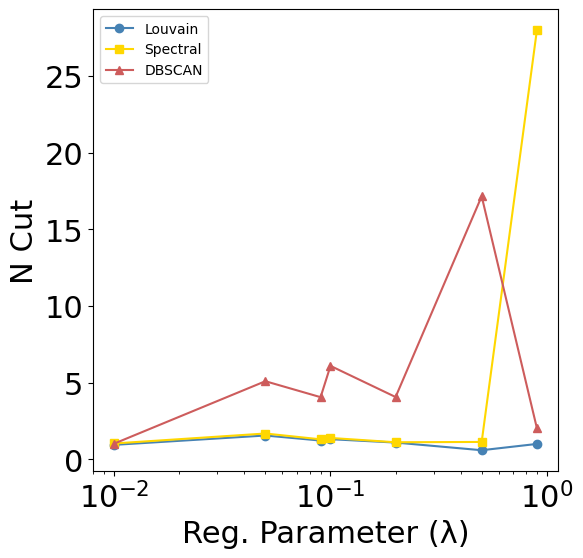

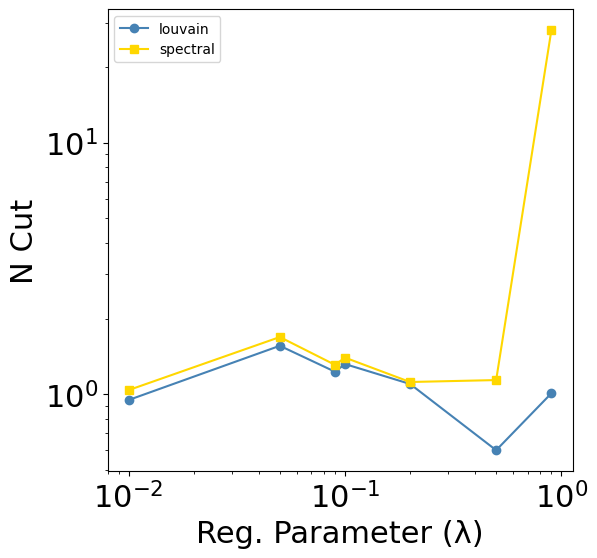

In [10]:
plot_results('ncut', 'N Cut', lists)
plot_results('ncut', 'N Cut', lists, ['louvain', 'spectral'])

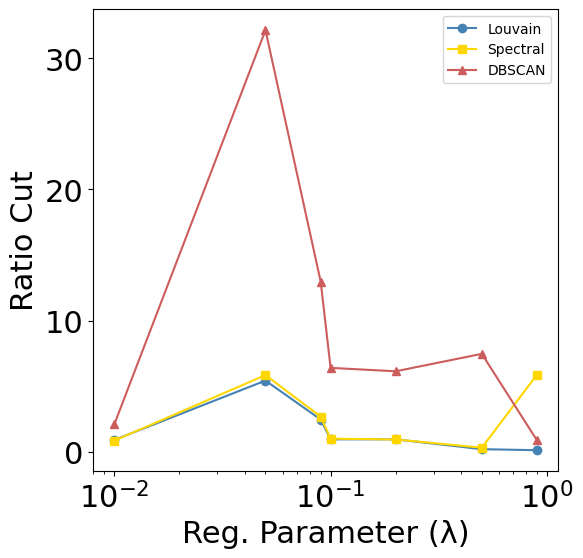

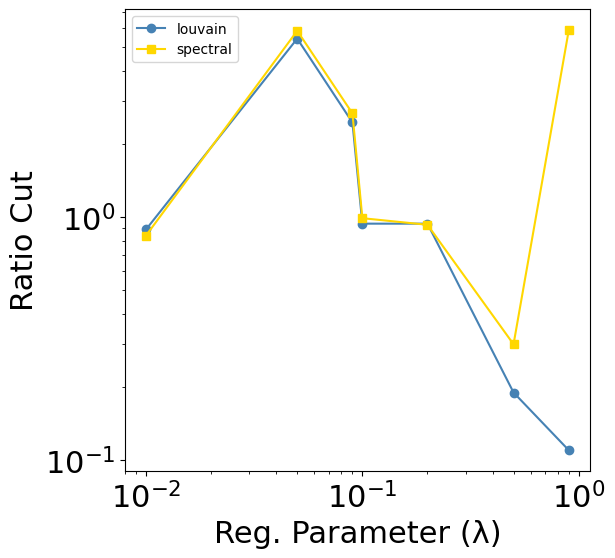

In [11]:
plot_results('rcut', 'Ratio Cut', lists)
plot_results('rcut', 'Ratio Cut', lists, methods=['louvain', 'spectral'])

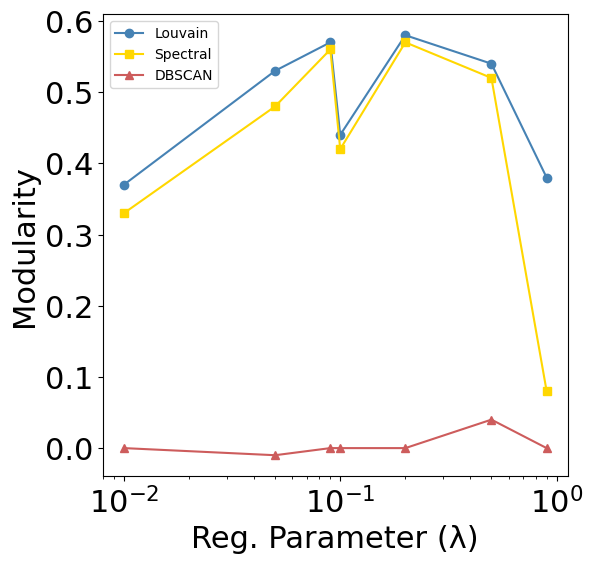

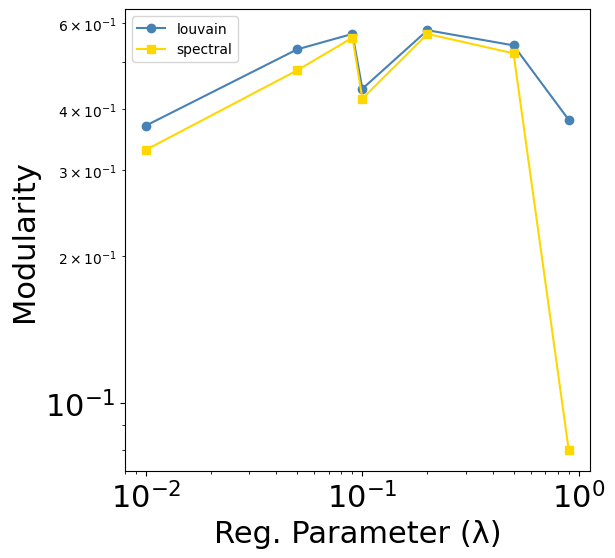

In [12]:
plot_results('modularity', 'Modularity', lists)
plot_results('modularity', 'Modularity', lists, methods=['louvain', 'spectral'])

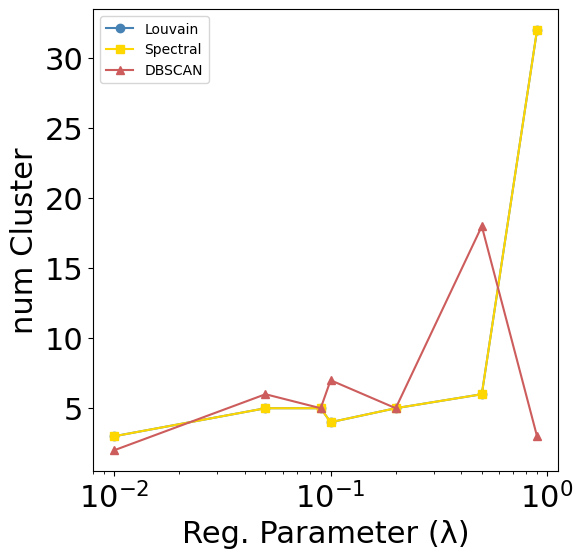

In [13]:
plot_results('nCluster', 'num Cluster', lists)

In [14]:
def plot_results_2(metrics, ylabel, results, methods=['louvain', 'spectral', 'dbscan']):
    # Create the plot
    plt.figure(figsize=(6, 6))

    colors = ['steelblue', 'gold', 'indianred']
    dot = ['o-', 's-', '^-']

    if methods == ['louvain', 'spectral']:
        for i, method in enumerate(methods): 
            plt.plot(results['rho_values'], results[f'{method}_{metrics}'], dot[i], label=f'{method}', color=colors[i])
        
        plt.yscale('log')
    
    else:
        plt.plot(results['rho_values'], results[f'louvain_{metrics}'], 'o-', label='Louvain', color=colors[0])
        plt.plot(results['rho_values'], results[f'spectral_{metrics}'], 's-', label='Spectral', color=colors[1])
        plt.plot(results['rho_values'], results[f'dbscan_{metrics}'], '^-', label='DBSCAN', color=colors[2])
    # plt.plot(results['rho_values'], results[f'dbscan_{metrics}'], '^-', color=colors[0])


    plt.xlabel('Reg. Parameter (λ)', fontsize=22)
    plt.ylabel(ylabel, fontsize=22)
    plt.xscale('log')
    plt.yscale('log')
    plt.tick_params(axis='x', labelsize=22)
    plt.tick_params(axis='y', labelsize=22)
    plt.show()

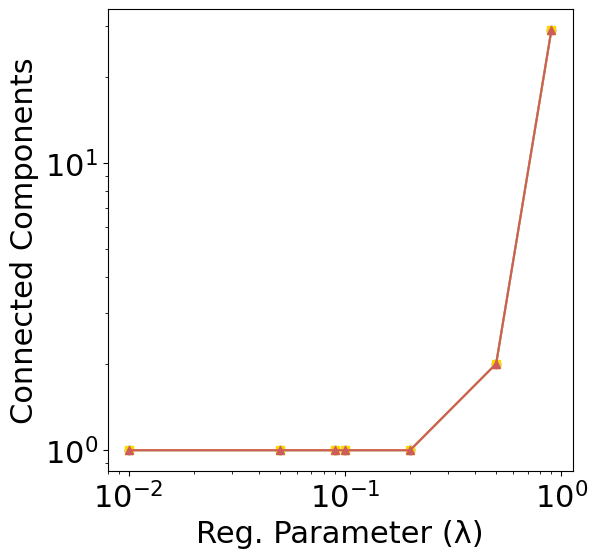

In [15]:
plot_results_2('CC', 'Connected Components', lists)